In [1]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

In [2]:
# custom values
EDGE_LENGTH = 1e-2 
EDGE_OFFSET = 1e-3 

# given paramters
RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.0
LLS = 0.001
SD = 0.005
SH = 0.01

In [3]:
# depending on task
CURRENT_1 = 1     # Ampere
AREA_COIL_1 = SD * 2 * SH

CURRENT_2 = 0
AREA_COIL_2 = SH * SD

MU_DEFAULT = 1

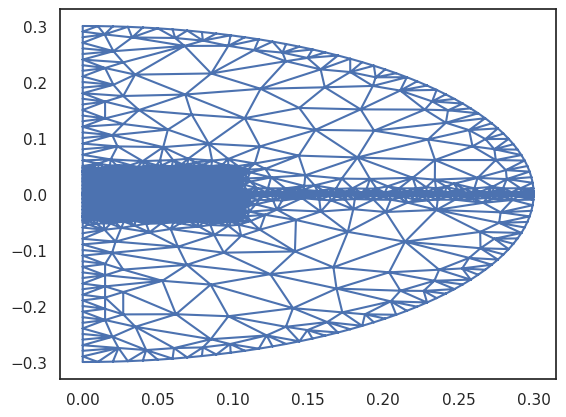

In [4]:
def beta(x, y):
    return 0

nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Loesung_FEM_WS1920/KlausurWS1920_Netz.npz", show=True)

#______________
# Dirichlet Boundary
def dirichlet_func(x, y):
    return 0

# all knots where r=0
DIRICHLET_INDICES = np.array(mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces, [[0, RA], [0, -RA]], ["Nodes"])).flatten()

#______________
# Robin Boundary
def robin_rhs(x, y):
    return 0

# robin indices should be all segments of the the half circle
BOUNDARY_POINTS = [[0,-RA],[RA, 0],[0,RA]]
ROBIN_INDICES = mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces,BOUNDARY_POINTS, ["Segments", "Segments"])
ROBIN_INDICES = np.concatenate([ROBIN_INDICES[0], ROBIN_INDICES[1]])

# Knotenidizes zu [R0,0], [R1,0], [R2,0]
Ps=[[DD,0],[BM-DD,0],[BM,0]]
fnodes=mt.FindClosestNode(range(len(nodes)),nodes,Ps)
node0=fnodes[0][0]
node1=fnodes[0][1]
node2=fnodes[0][2]

In [5]:
def get_inductance_by_permability(mu1, mu2, current1, current2):

    def _current_density(x, y):
    # Ensure inputs are NumPy arrays
        x = np.asarray(x)
        y = np.asarray(y)

        # Masks for each coil region
        coil_1_mask = (
            (x >= DD + LLS) & (x <= DD + LLS + SD) &
            (y >= -SH) & (y <= SH)
        )

        coil_2_mask = (
            (x >= BM + LLS) & (x <= BM + LLS+ SD) &
            (y >= -SH/2) & (y <= SH/2)
        )
        coil_2_inv_mask = (
            (x >= BM - DD - LLS - SD) & (x <= BM - DD - LLS) &
            (y >= -SH/2) & (y <= SH/2)
        )

        # Current density values per region
        J = np.zeros_like(x, dtype=float)
        J = np.where(coil_1_mask, current1 / AREA_COIL_1, J)
        J = np.where(coil_2_mask, current2 / AREA_COIL_2, J)
        J = np.where(coil_2_inv_mask, -current2 / AREA_COIL_2, J)

        return J


    def rhs(x, y):
        # Ensure x and y are NumPy arrays
        x = np.asarray(x)
        y = np.asarray(y)

        # Optionally restore magnetic difference terms here
        # mag_diff_r = - M0 * 2 / MA * 6 * (x - RM0)**5
        # mag_diff_z = - M0 * 2 / MB * 6 * (y - ZM0)**5
        mag_diff_r = 0
        mag_diff_z = 0

        return _current_density(x, y) + mag_diff_r + mag_diff_z

    def _magnetic_pernmability(x, y):
    # Light gray regions (Material 1)
        left_wall = (0 <= x) & (x <= DD) & (-HM/2 <= y) & (y <= HM/2)
        bottom_wall = (0 <= x) & (x <= BM - DD) & (-HM/2 <= y) & (y <= -HM/2 + DD)
        top_wall = (0 <= x) & (x <= BM - DD) & (HM/2 - DD <= y) & (y <= HM/2)

        # Dark gray region (Material 2)
        right_wall = (BM - DD <= x) & (x <= BM) & (-HM/2 <= y) & (y <= HM/2)

        # Combine masks
        inside_mu1 = left_wall | bottom_wall | top_wall
        inside_mu2 = right_wall

        # Assign μ values
        mu = np.where(inside_mu1, mu1, np.where(inside_mu2, mu2, MU_DEFAULT))

        return mu * sci.constants.mu_0
    
    def alpha1(x, y):
        mu =  _magnetic_pernmability(x, y)
        if mu == 0:
            return 0
        else:
            return 1 / (mu  * x) 

    def alpha2(x, y):
        return alpha1(x, y)
    
    def robin_gamma(x, y):
        mu = _magnetic_pernmability(x, y)
        if np.isclose(x, 0) or np.isclose(y, 0) or np.isclose(mu, 0):  # TODO: this is a hacky solution. handle the robin indicies creation better! 
            return 0
        return 1 / ( mu * x * np.sqrt(np.power(x, 2) + np.power(y, 2)) )
    
    stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
    stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
    stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

    solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)

    def inductance(current, point_1, point_2):

        mask_1 = (
            np.isclose(solution["x"], point_1[0]) &
            np.isclose(solution["y"], point_1[1])
        )
        value_1 = solution.loc[mask_1, "Phi"].values[0]

        mask_2 = (
            np.isclose(solution["x"], point_2[0]) &
            np.isclose(solution["y"], point_2[1])
        )
        value_2 = solution.loc[mask_2, "Phi"].values[0]

        magnetic_flux = 2 * np.pi * (value_1 - value_2)

        return magnetic_flux / current

    inducance_1 = inductance(current1, nodes[node0], [0,0])
    inductance_2 = inductance(-current2, nodes[node1], nodes[node2])
    mutual_inductance = inductance(-current2, nodes[node0], [0,0])

    return inducance_1, inductance_2, mutual_inductance

Permability:  1


/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current
/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current


Inductance Coil 1:  1.2710159527838675e-08
Inductance Coil 2: 2.1683788101388866e-07
Mutual Inductance: 6.134318747982091e-10
Coupling Factor:  0.011684853203601245 

Permability:  10


/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current
/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current


Inductance Coil 1:  7.167690509176645e-08
Inductance Coil 2: 7.61913998319122e-07
Mutual Inductance: 2.1385534628945188e-08
Coupling Factor:  0.09151188750432251 

Permability:  50


...

/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current
/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current


Inductance Coil 1:  2.1341648406008472e-05
Inductance Coil 2: 2.2437537492429107e-05
Mutual Inductance: 2.125569685062826e-05
Coupling Factor:  0.9713455867068543 

Permability:  10000


/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current


Inductance Coil 1:  4.2641951670794646e-05
Inductance Coil 2: 4.373859764323112e-05
Mutual Inductance: 4.255593297733142e-05
Coupling Factor:  0.9853922725009392 



/tmp/ipykernel_2031/2828325868.py:101: RuntimeWarning: divide by zero encountered in scalar divide
  return magnetic_flux / current


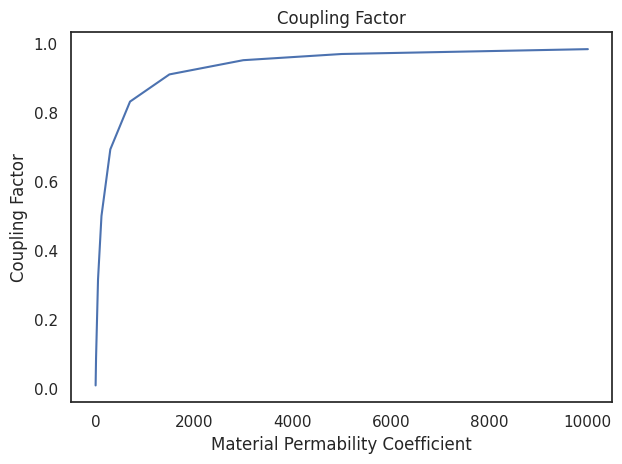

In [6]:
permabilities = [1, 10, 50, 120, 300, 700, 1500, 3000, 5000, 10000]
coupling_factors = []

for permability in permabilities:
    print("Permability: ", permability)
    
    inducance_1, _, mutual_inductance = get_inductance_by_permability(permability, permability, 1,0)
    _, inductance_2, mutual_inductance = get_inductance_by_permability(permability, permability, 0,1)

    print(f"Inductance Coil 1: ", inducance_1)
    print(f"Inductance Coil 2: {inductance_2}")
    print(f"Mutual Inductance: {mutual_inductance}")

    coupling_factor =  mutual_inductance / np.sqrt(inducance_1 * inductance_2)
    coupling_factors.append(coupling_factor)
    print(f"Coupling Factor: ",coupling_factor, "\n")


plt.plot(permabilities, coupling_factors)

plt.title(f"Coupling Factor")
plt.xlabel("Material Permability Coefficient")
plt.ylabel("Coupling Factor")

plt.tight_layout()
plt.show()